# EDA - Using matched treatment and control groups only

## Check calendar 2 high price matching

In [1]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 3, Finished, Available, Finished, False)

In [2]:
%run ./consumption_plot

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 4, Finished, Available, Finished, True)

In [3]:
%run ./peak_plot

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 5, Finished, Available, Finished, True)

In [4]:
%run ./consumption_cohort

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 6, Finished, Available, Finished, True)

## Load Data 

### Adopt matching result

In [5]:
# Change here !!!
match_method = "calendar2_1year"

# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 7, Finished, Available, Finished, False)

In [6]:
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
matches["cohort"] = pd.to_datetime(matches["adoption_month"]).dt.to_period("M") # add!
print(matches.head())

treated_ids = matches["treated_id"].unique()
control_ids = matches["control_id"].unique()
print(f"Treated IDs: {len(treated_ids)}, Control IDs: {len(control_ids)}")

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 8, Finished, Available, Finished, False)

           treated_id          control_id adoption_month  distance  valid_dim  \
0  735999166200137406  735999166201588467     2025-10-01  0.056840          5   
1  735999166200137406  735999166200200018     2025-10-01  0.056862          5   
2  735999166200137406  735999166202144495     2025-10-01  0.061165          5   
3  735999166200137406  735999166204733253     2025-10-01  0.061480          5   
4  735999166200137406  735999166202887996     2025-10-01  0.068502          5   

   match_rank   cohort  
0           1  2025-10  
1           2  2025-10  
2           3  2025-10  
3           4  2025-10  
4           5  2025-10  
Treated IDs: 1696, Control IDs: 7527


### Consumption data

In [7]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")
print(month_result.shape)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 9, Finished, Available, Finished, False)

(4538578, 17)


In [8]:
# Consumption data
# treated mapping
treated_map = matches[["treated_id", "cohort"]].drop_duplicates()
treated_map.columns = ["aID", "cohort"]
treated_map["treatment"] = 1

# control mapping
control_map = matches[["control_id", "cohort"]].copy()
control_map.columns = ["aID", "cohort"]
control_map["treatment"] = 0

match_map = pd.concat([treated_map, control_map], axis=0)

print(match_map.head())


# merge 
month_result = month_result.merge(
    match_map,
    on="aID",
    how="inner"
)

print(month_result.shape)
month_result.head()

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 10, Finished, Available, Finished, False)

                   aID   cohort  treatment
0   735999166200137406  2025-10          1
5   735999166200193587  2025-10          1
10  735999166200271612  2025-10          1
15  735999166200436967  2025-10          1
20  735999166200437223  2025-10          1
(934439, 19)


,aID,TIDPUNKT,price,tariff_active,peak1_time,peak1_consumption,peak2_time,peak2_consumption,peak3_time,peak3_consumption,top3_mean_consumption,variance_consumption,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group,cohort,treatment
0,735999166200186312,2025-08-01,low,0,2025-08-27 12:00:00,4.88400000,2025-08-31 01:00:00,4.69100000,2025-08-30 11:00:00,4.46300000,4.679333,0.700982,0.641600806452,NaT,None,28275.40600000,medium,2025-03,0
1,735999166200186312,2024-10-01,all,0,2024-10-27 01:00:00,5.06800000,2024-10-06 01:00:00,5.03900000,2024-10-07 13:00:00,4.64600000,4.917667,0.606204,0.746803763441,NaT,None,28275.40600000,medium,2025-03,0
2,735999166200186312,2024-09-01,low,0,2024-09-15 01:00:00,5.39200000,2024-09-28 12:00:00,4.85300000,2024-09-01 13:00:00,4.24400000,4.829667,0.413675,0.550377777778,NaT,None,28275.40600000,medium,2025-03,0
3,735999166200186312,2024-12-01,low,0,2024-12-24 11:00:00,7.46200000,2024-12-07 12:00:00,6.38800000,2024-12-31 16:00:00,5.57000000,6.473333,1.275615,1.309984313725,NaT,None,28275.40600000,medium,2025-03,0
4,735999166200186312,2026-01-01,low,0,2026-01-31 11:00:00,6.64500000,2026-01-14 23:00:00,5.99800000,2026-01-11 00:00:00,5.89300000,6.178667,1.264656,2.468555785124,NaT,None,28275.40600000,medium,2025-03,0


## Electricity data

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 11, Finished, Available, Finished, False)

Before: 381762
After: 333459
Before: 934439
After: 816354


<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

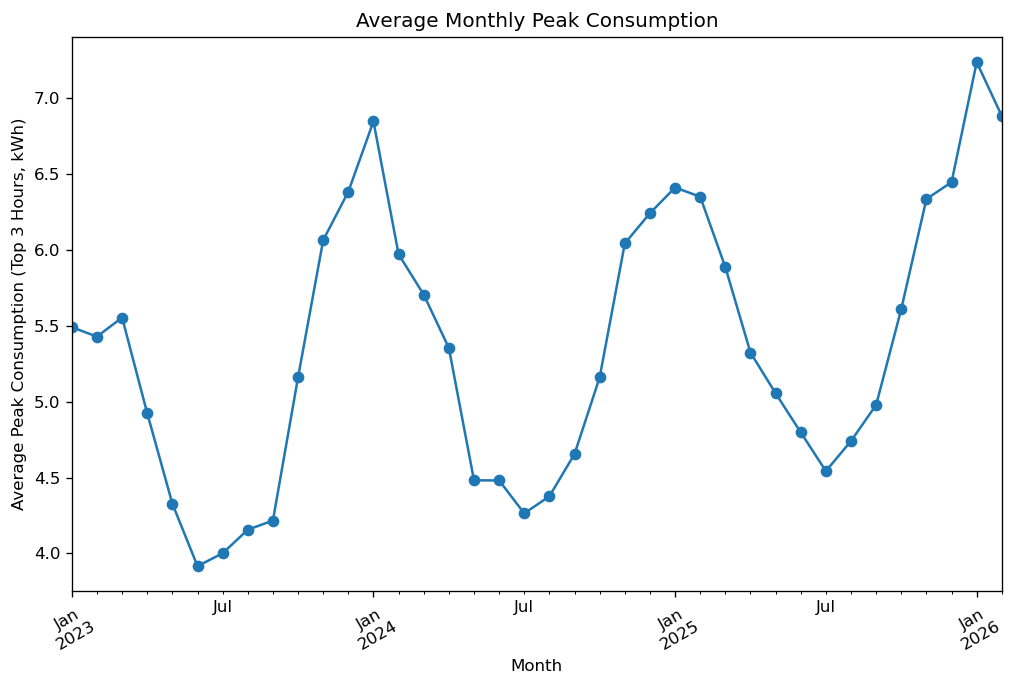

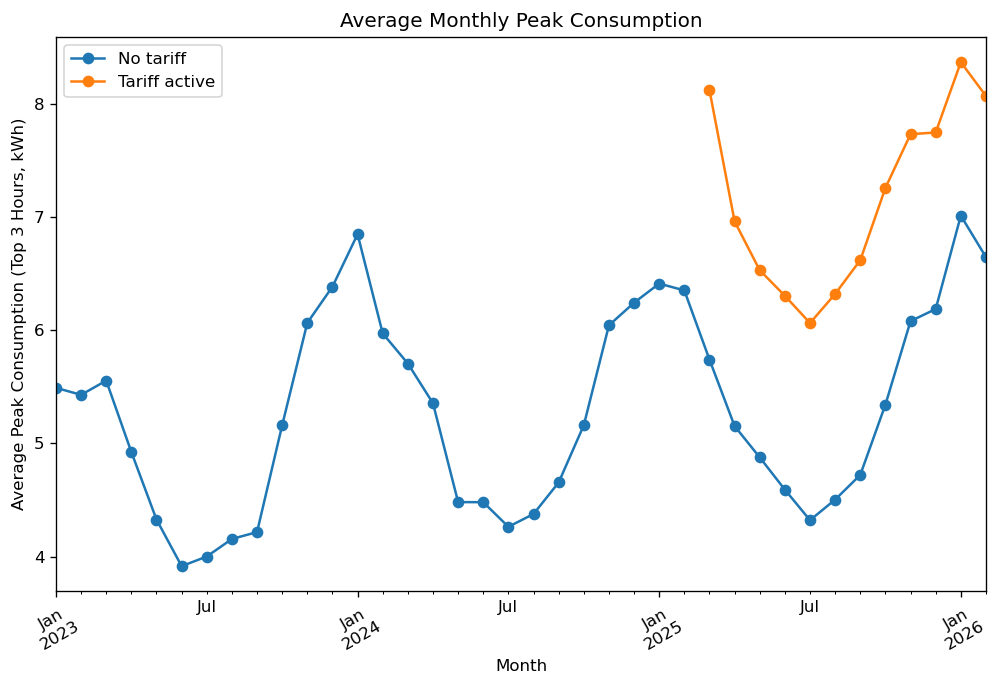

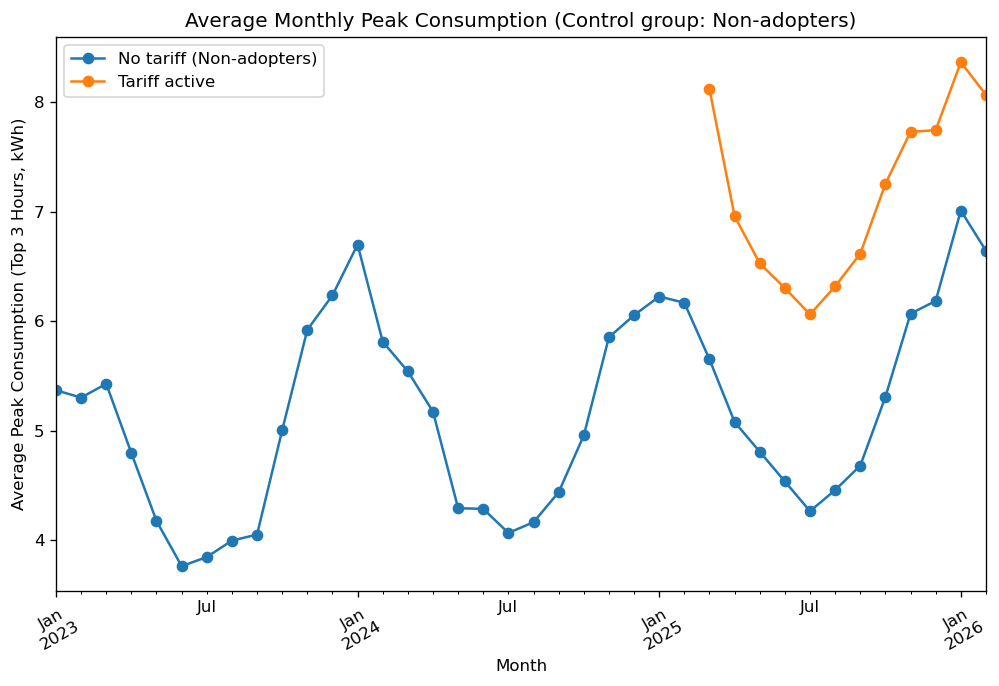

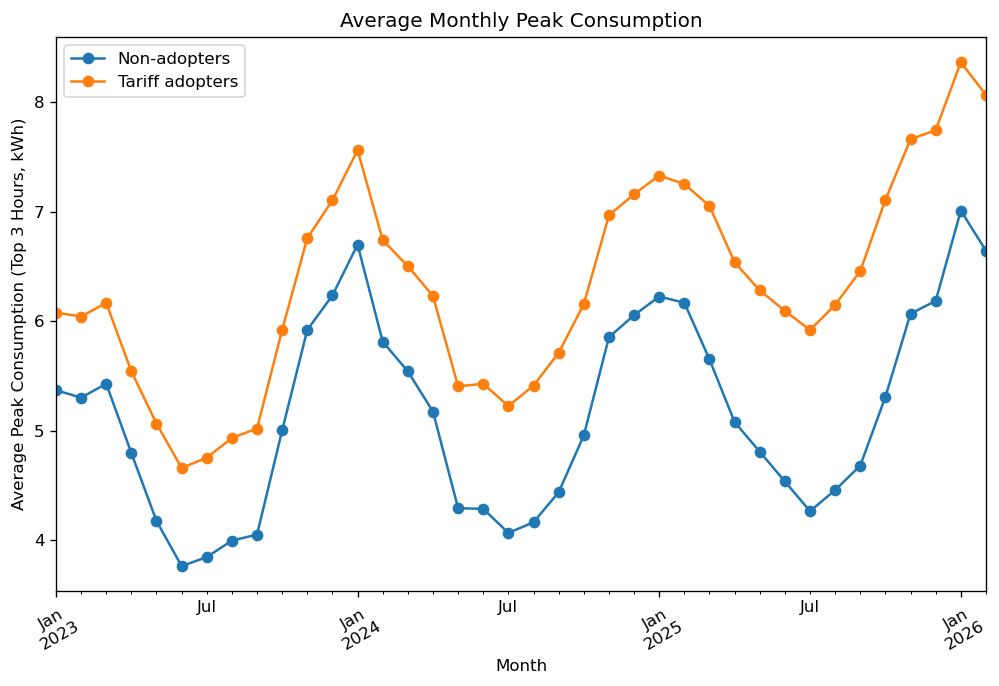

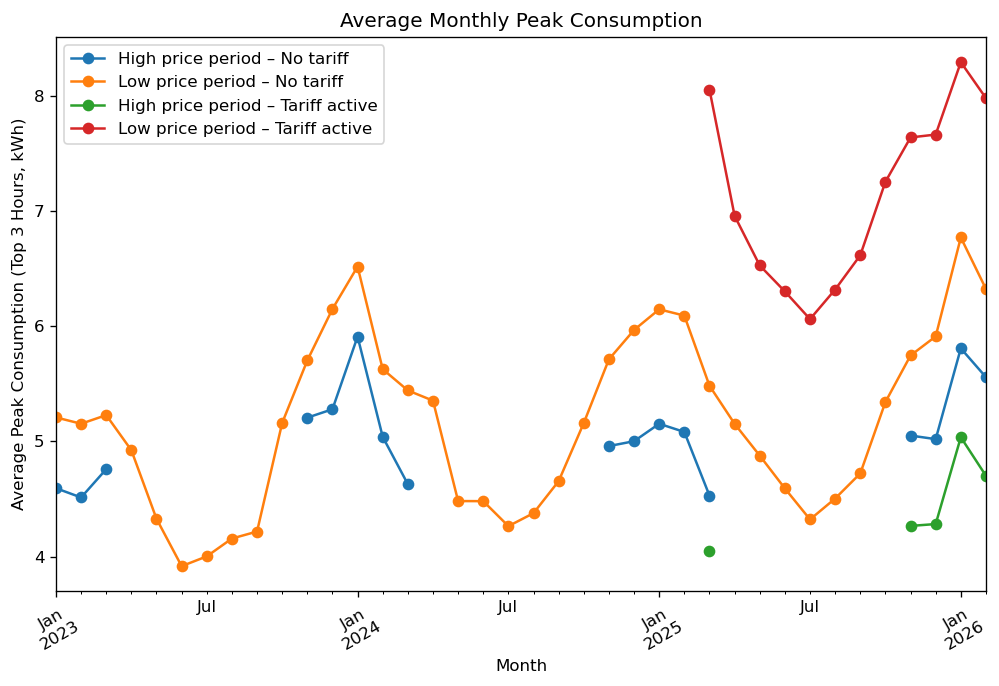

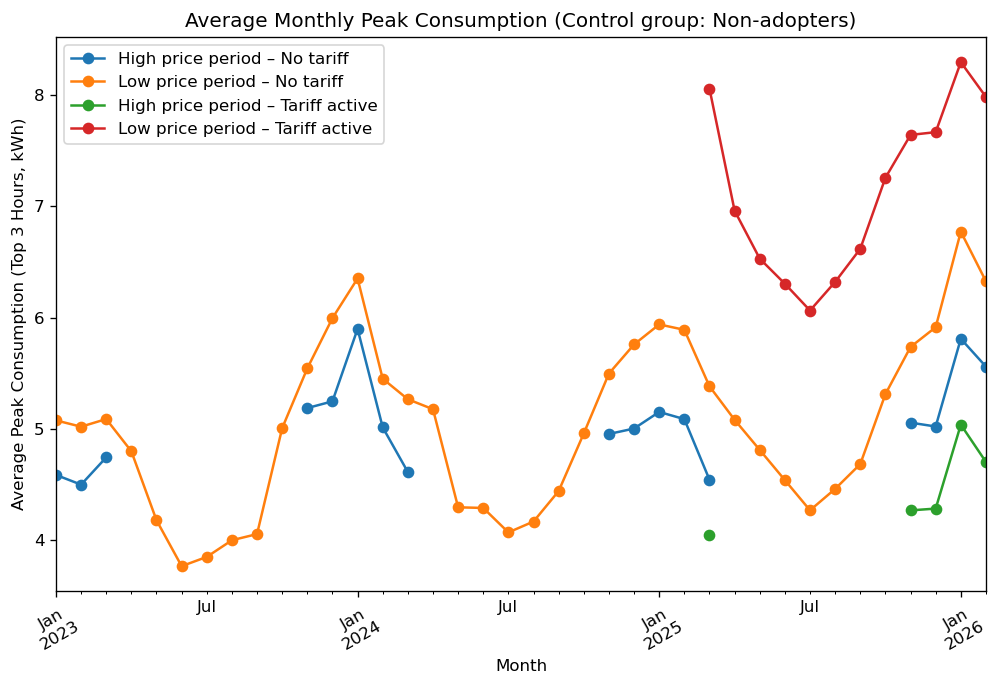

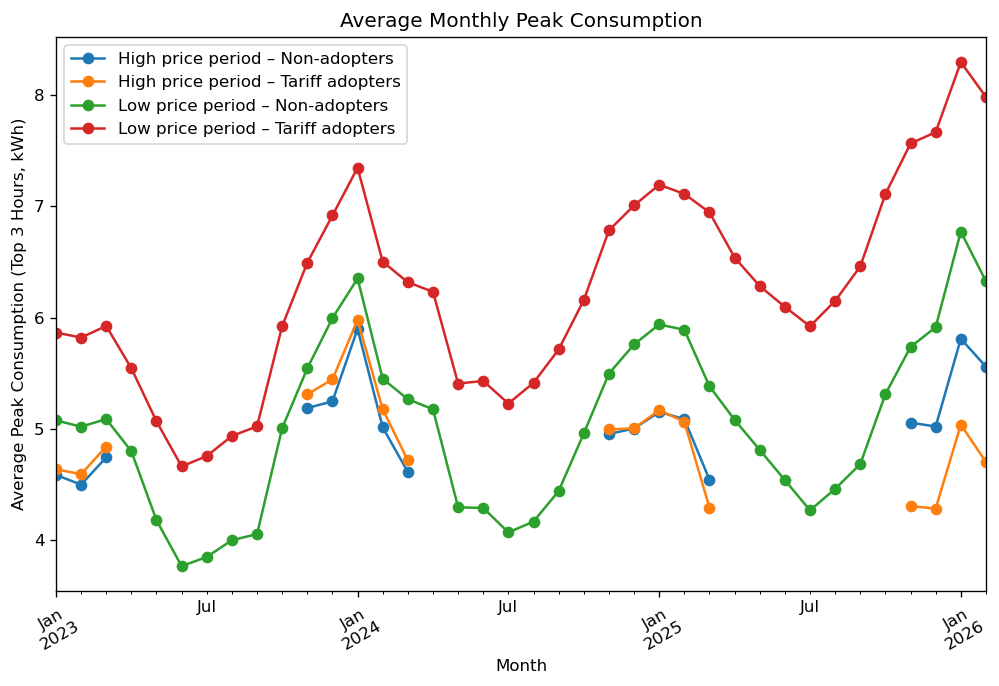

In [9]:
# month
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    show_legend=False
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

plot_tariff_adoption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption"
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"]
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"],
    exclude_future_tariff=True
)

plot_tariff_adoption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    by_price=True
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 12, Finished, Available, Finished, False)

array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

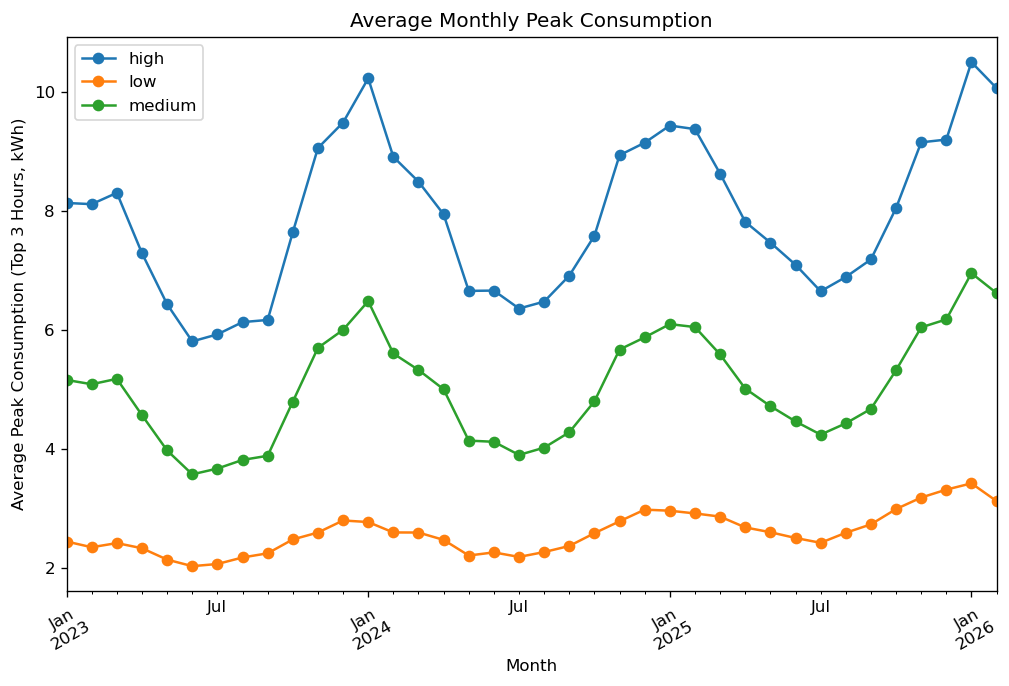

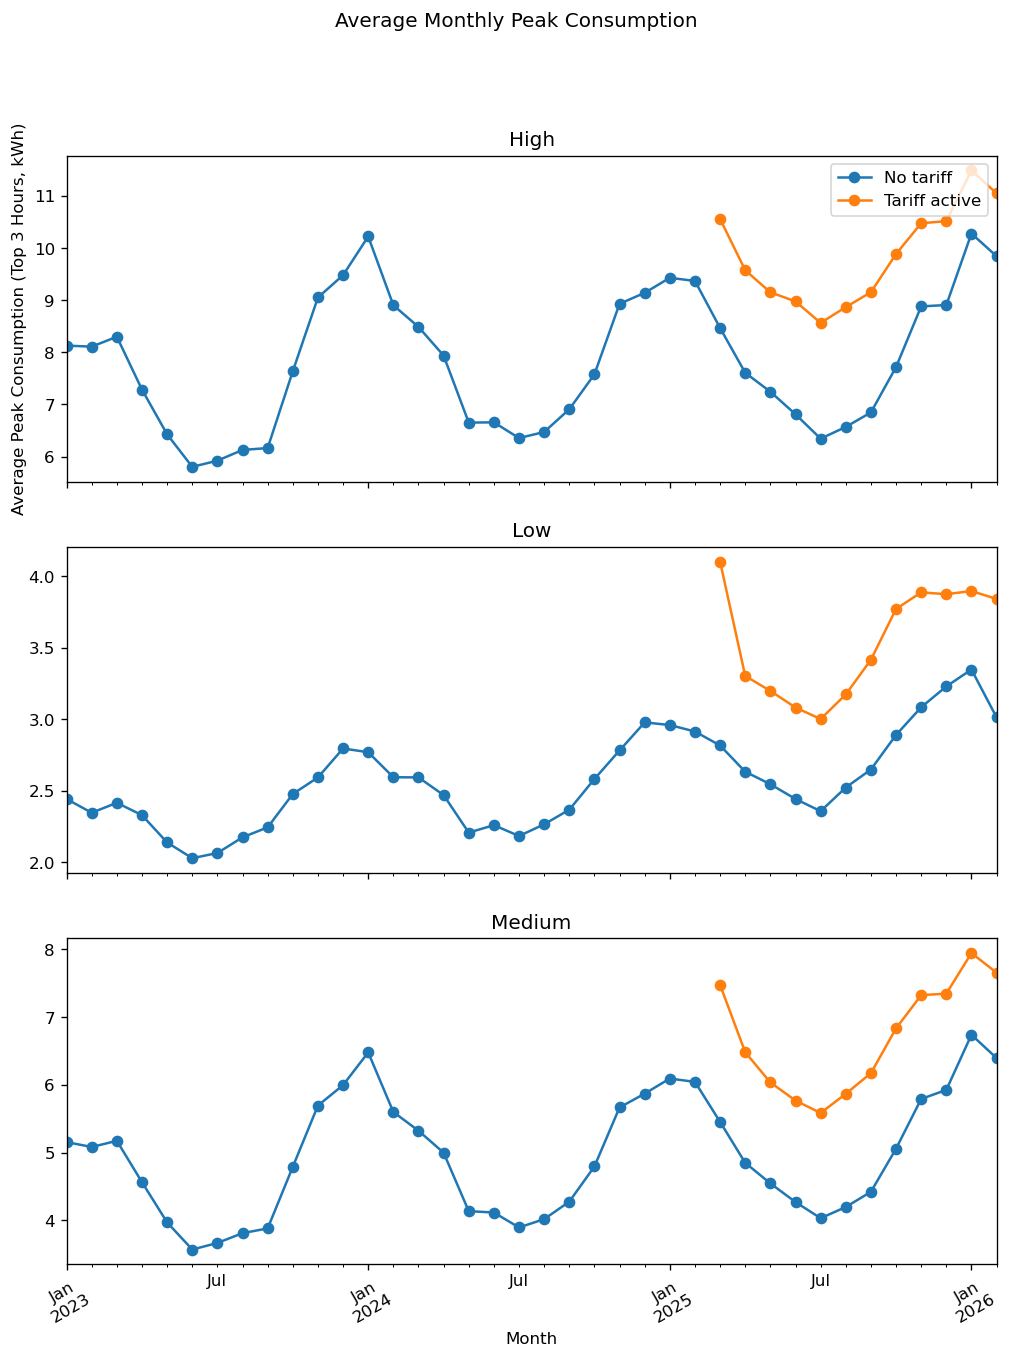

In [10]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group"]
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    facet_by="usage_group"
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 13, Finished, Available, Finished, False)

Before: 381762
After: 333459


array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

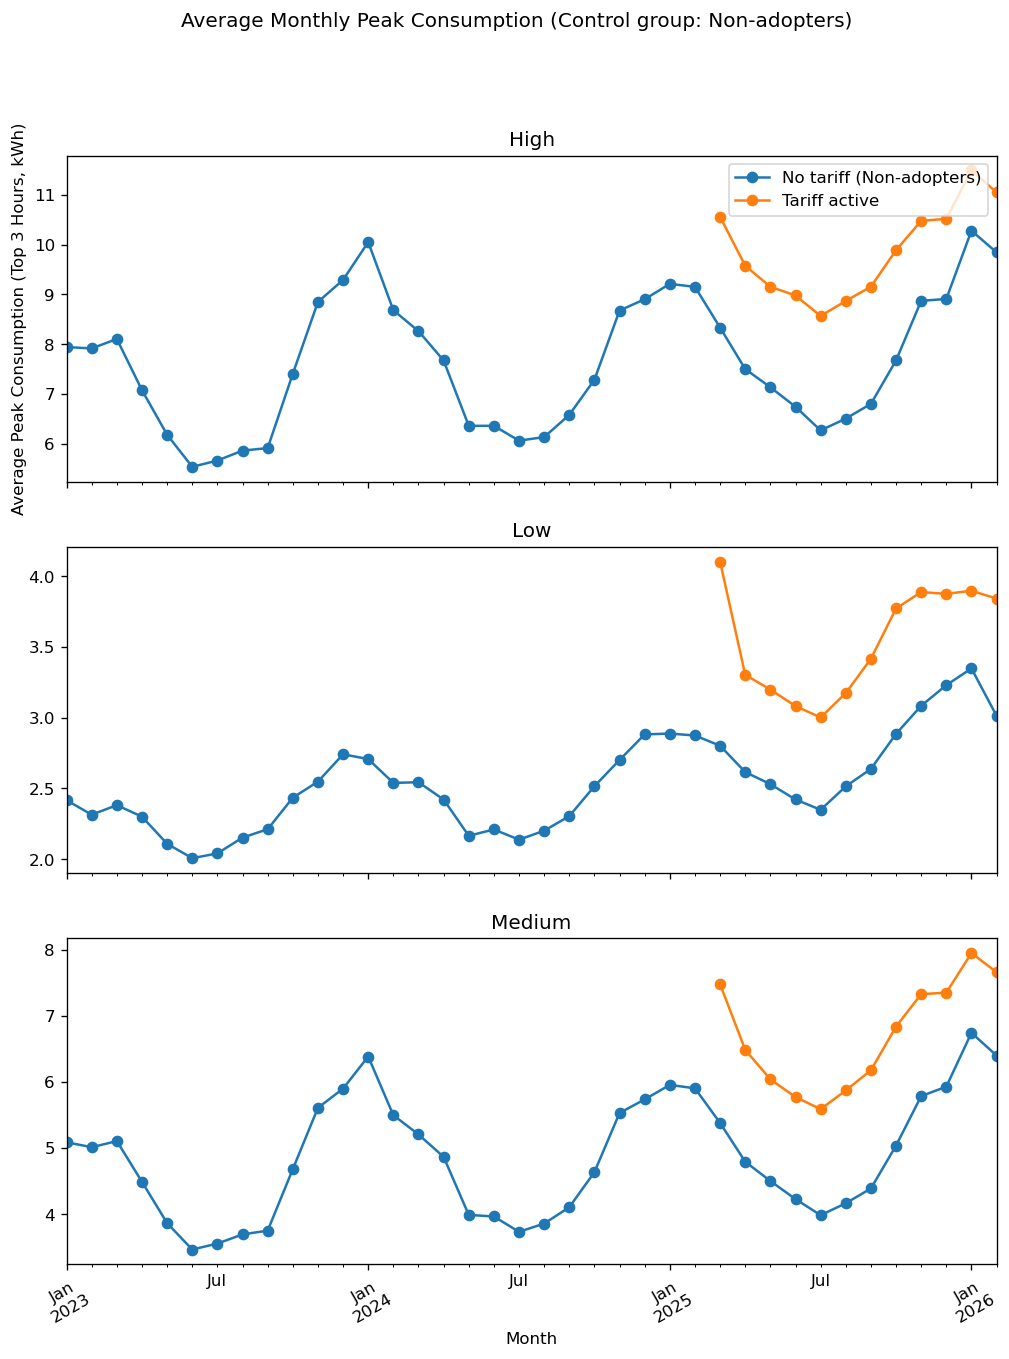

In [11]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    exclude_future_tariff=True,
    facet_by="usage_group"
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 14, Finished, Available, Finished, False)

<Axes: title={'center': 'Tariff Adoption by Household Usage Group'}, xlabel='Household Usage Group', ylabel='Share Choosing Tariff'>

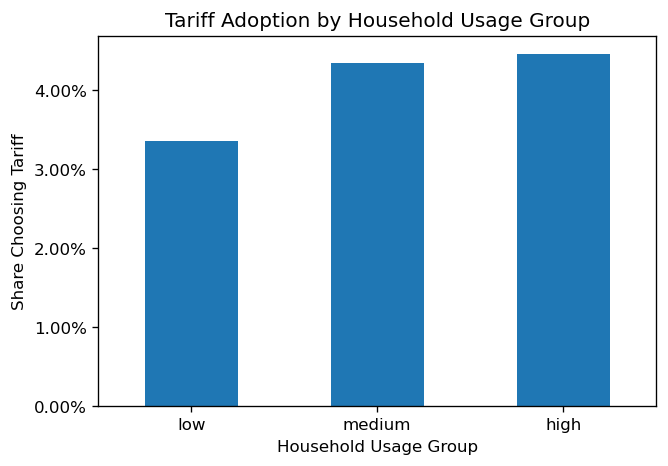

In [12]:
plot_tariff_adoption_by_usage(
    month_result[month_result["price"] == "all"],
    figsize=(6, 4)
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 15, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

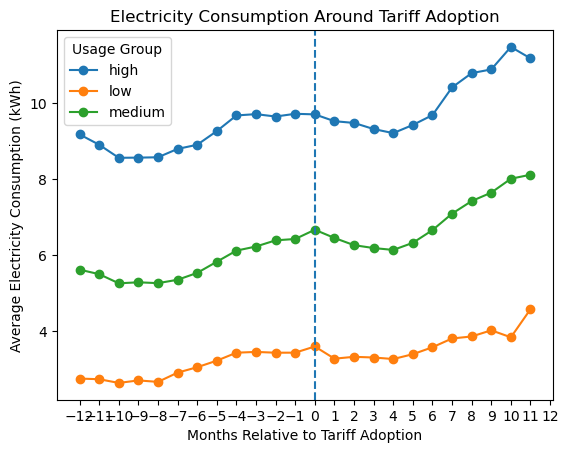

In [13]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 16, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

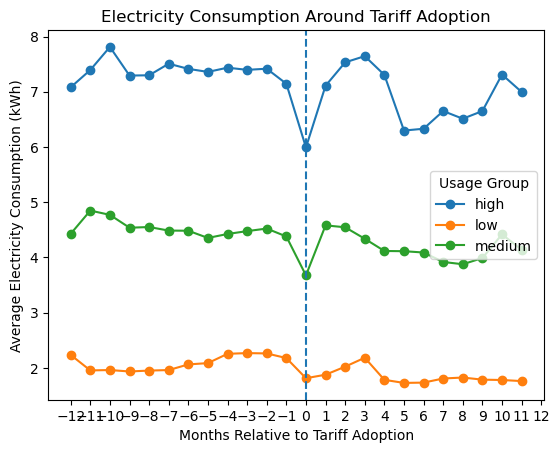

In [14]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 17, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

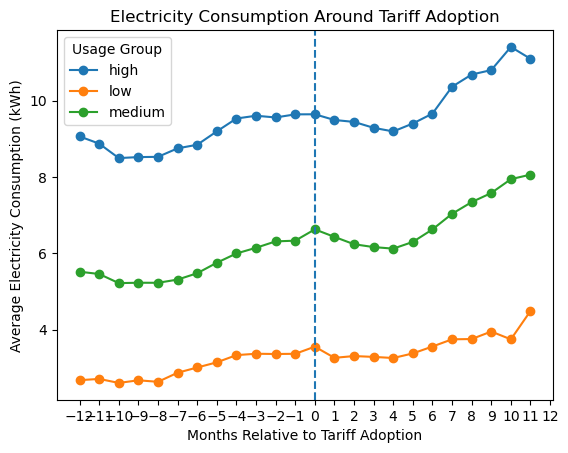

In [15]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 18, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

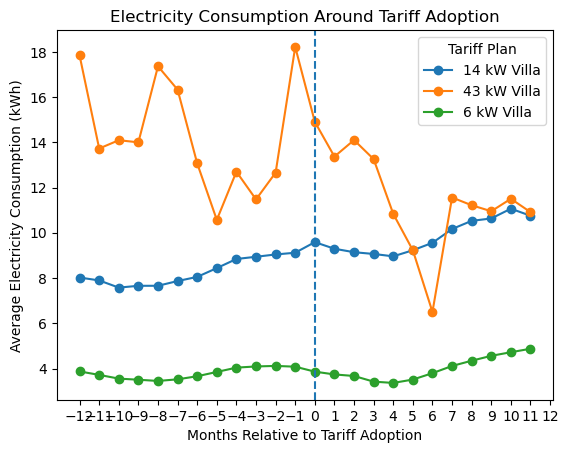

In [16]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 19, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

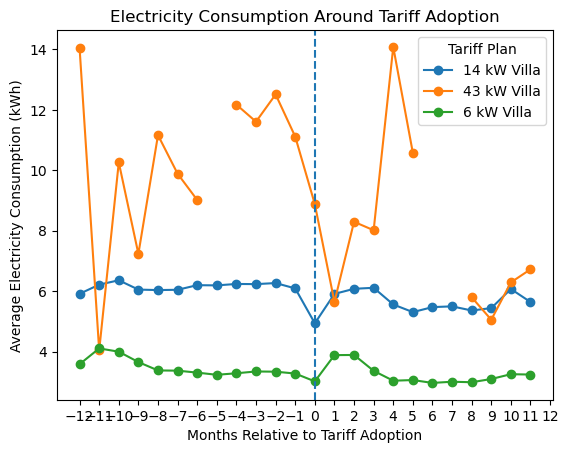

In [17]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 20, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

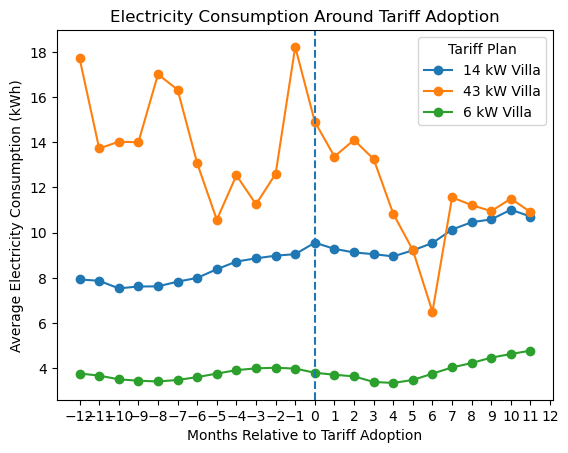

In [18]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 21, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

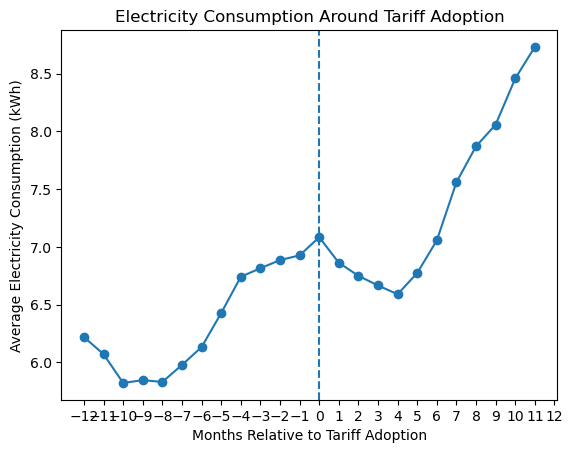

In [19]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 22, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

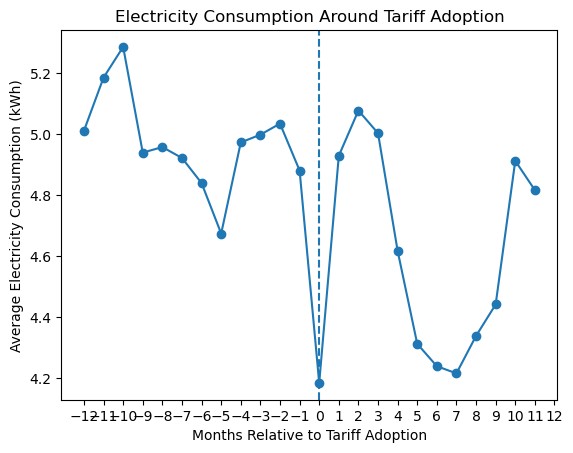

In [20]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 23, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

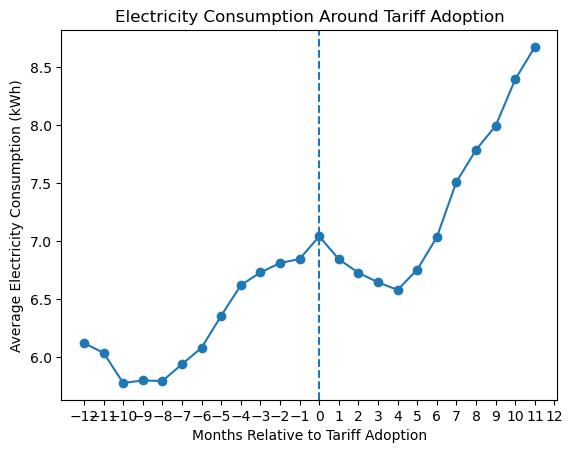

In [21]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 24, Finished, Available, Finished, False)

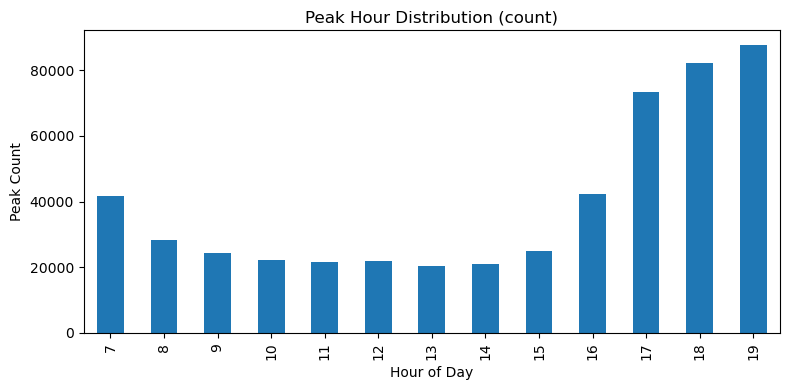

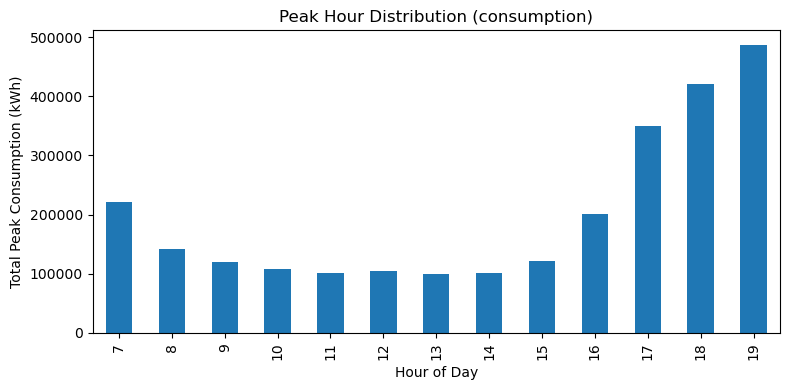

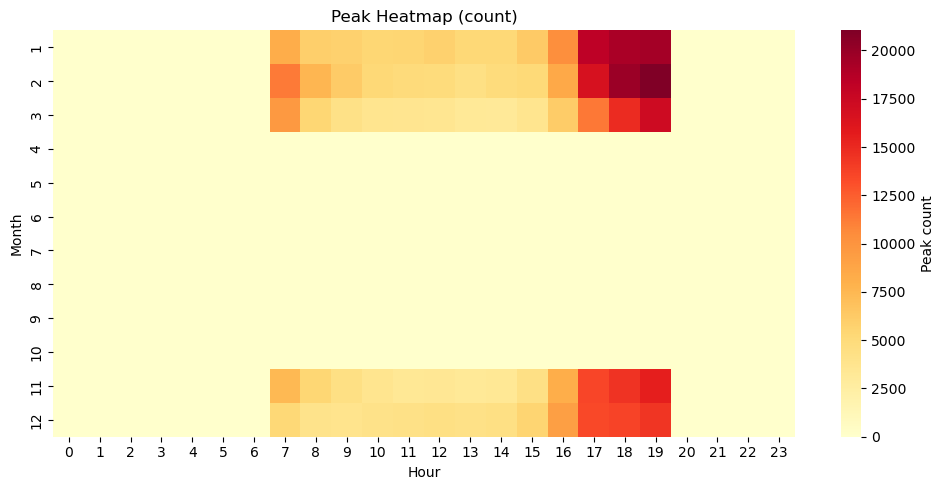

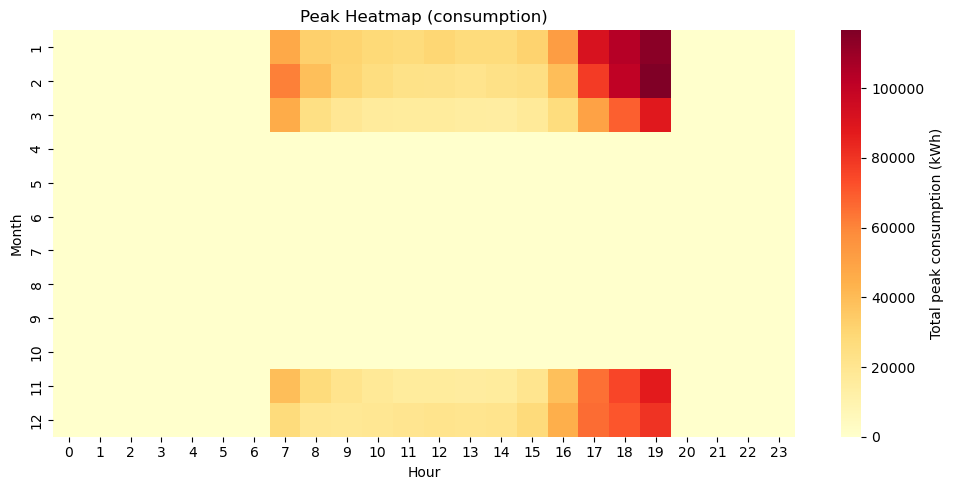

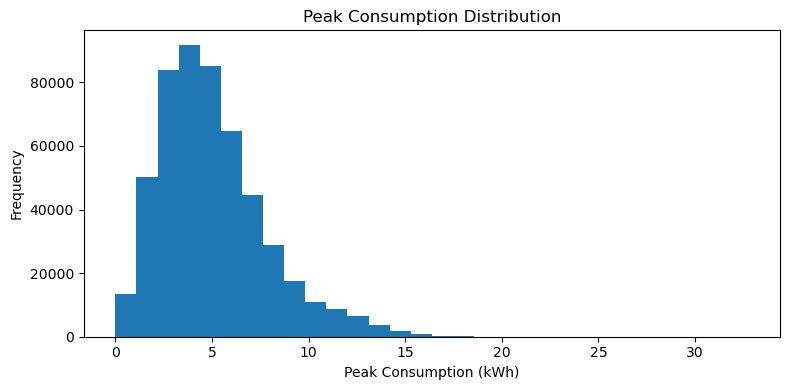

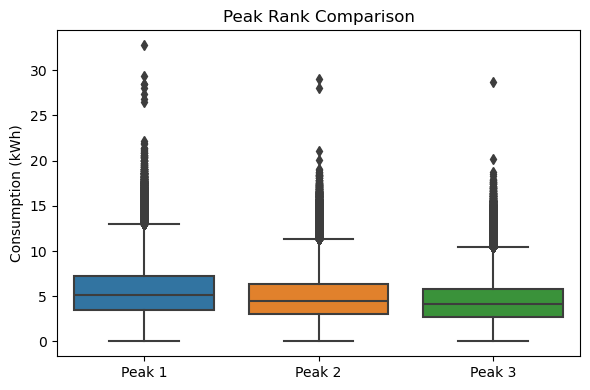

NameError: name 'plot_tariff_peak_heatmap' is not defined

In [ ]:
# Peak hour distribution (count)
# 看 peak 最常發生在一天的哪個小時
plot_peak_hour_distribution(month_result[month_result["price"] == "high"])

# Peak hour distribution (consumption)
# 看哪個小時的 peak 用電量總和最高（電網壓力）
plot_peak_hour_distribution(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak heatmap (count)
# Month × Hour heatmap，看不同月份 peak 最常出現的時間
plot_peak_heatmap(month_result[month_result["price"] == "high"])

# Peak heatmap (consumption)
# Month × Hour heatmap，但用顏色表示 peak 用電量
plot_peak_heatmap(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak consumption distribution
# Histogram，看 peak demand 的大小分布（household peak size）
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "high"]
)

# Peak rank boxplot
# 比較 peak1 / peak2 / peak3 的用電量分布，看 spike 程度
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "high"]
)

# Peak timing heatmap: P(hour | peak)
# 比較 tariff 前後 peak 發生次數的 Month × Hour heatmap
# plot_tariff_peak_heatmap(
#     month_result[month_result["price"] == "high"],
#     price_label="high"
# )

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)


StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 26, Finished, Available, Finished, False)

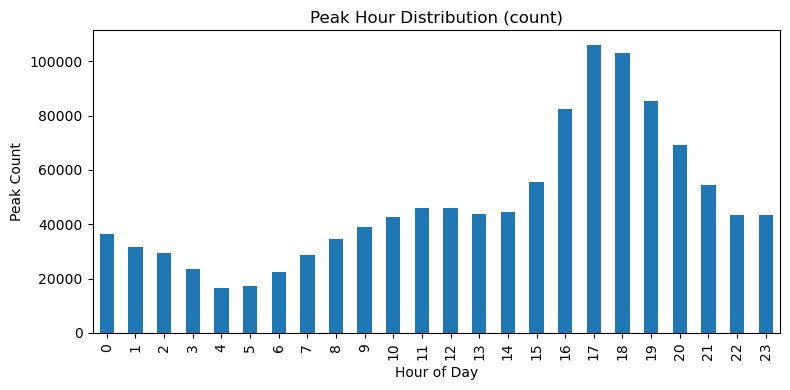

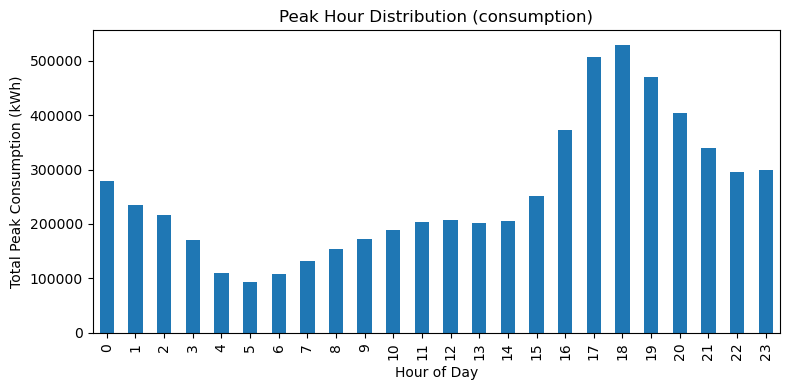

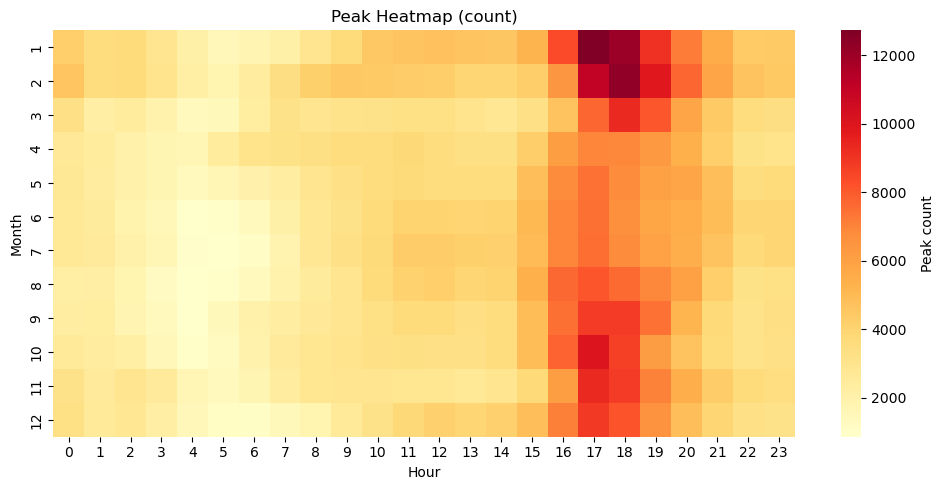

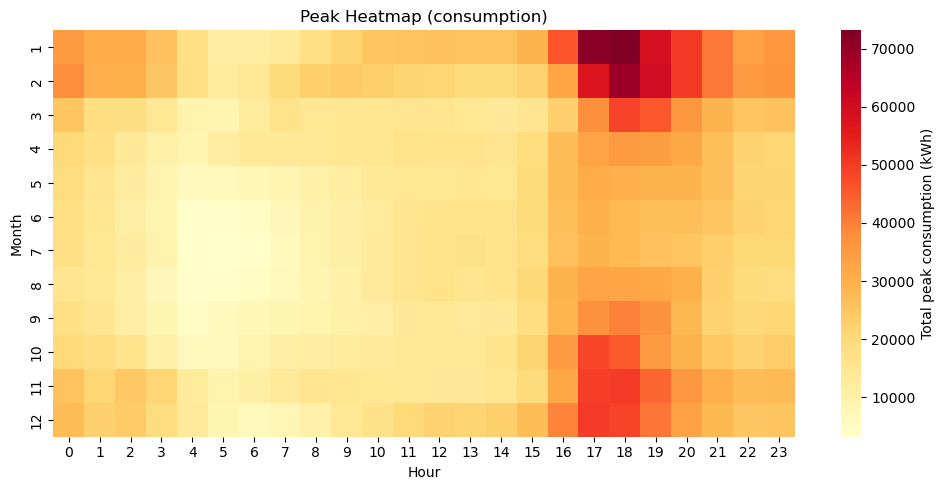

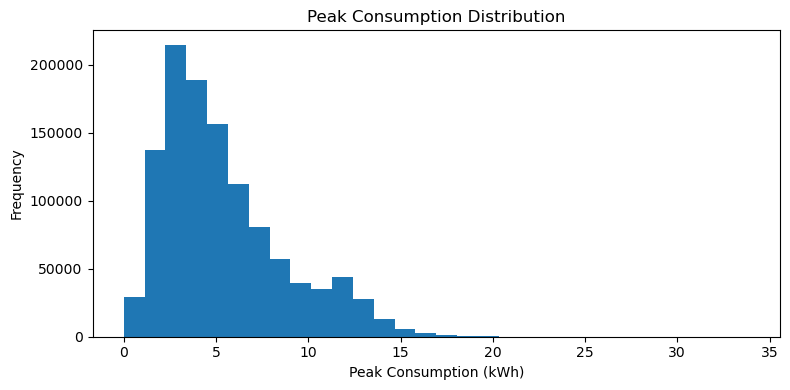

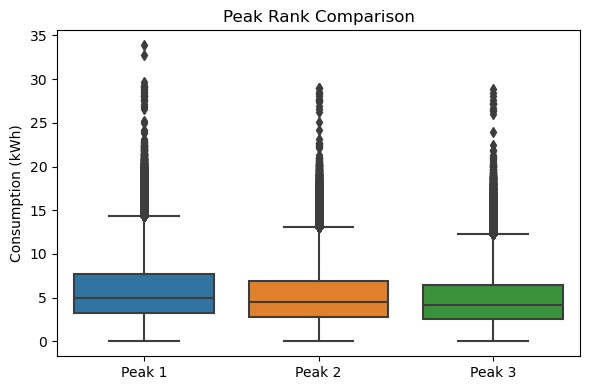

NameError: name 'plot_tariff_peak_heatmap' is not defined

In [ ]:
# Overall peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "all"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "all"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "all"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "all"]
)

# # Peak timing heatmap: P(hour | peak)
# plot_tariff_peak_heatmap(
#     month_result[month_result["price"] == "all"], 
#     price_label="all"
# )

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "all"],
    price_label="all"
)


StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, 27, Submitted, Running, Running, True)

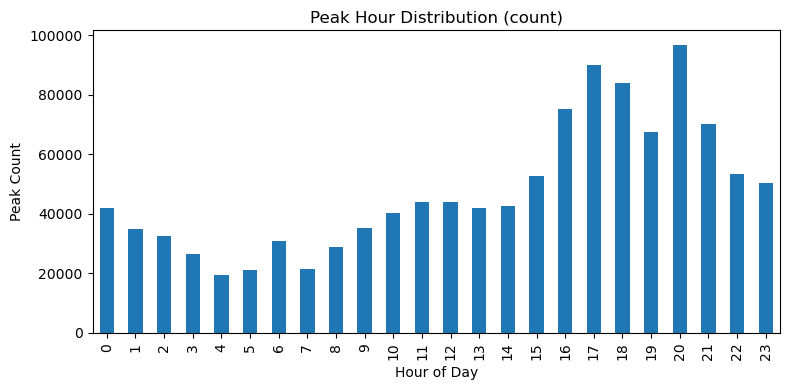

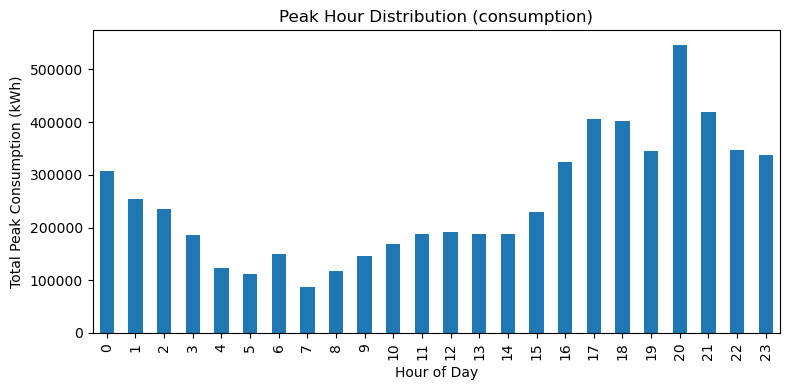

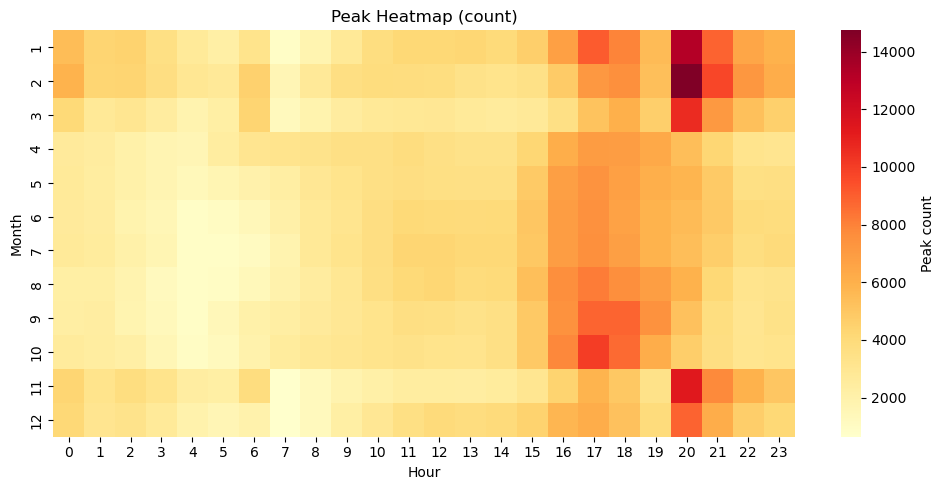

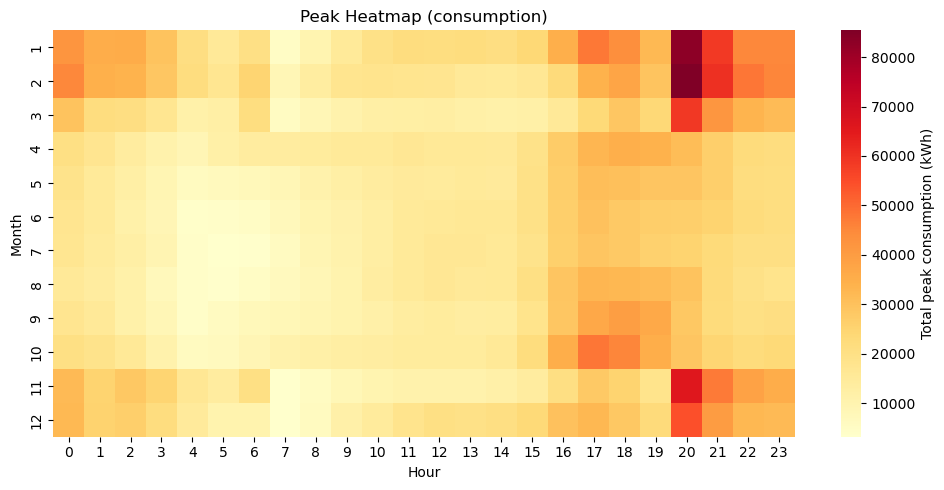

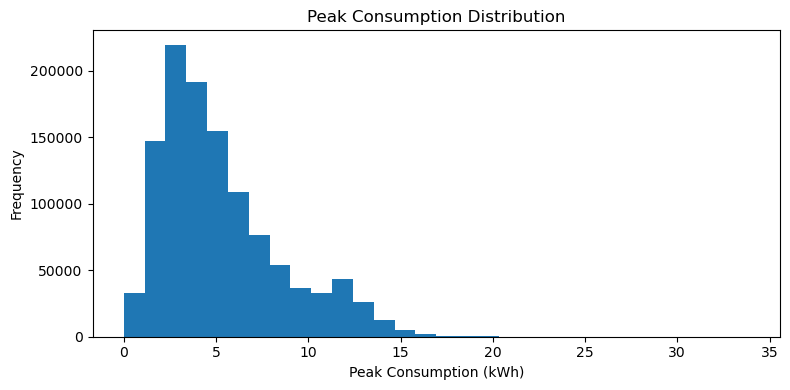

In [ ]:
# Low peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "low"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "low"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "low"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "low"]
)

# # Peak timing heatmap: P(hour | peak)
# plot_tariff_peak_heatmap(
#     month_result[month_result["price"] == "low"],
#     price_label="low"
# )


# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


## Look at specific month

In [ ]:
# plot_cohort_calendar(
#     month_result[month_result["price"] == "all"],
#     cohort_month="2025-03"
# )
# plot_cohort_calendar(
#     month_result[month_result["price"] == "all"],
#     cohort_month="2025-04"
# )

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, -1, Cancelled, , Cancelled, True)

In [ ]:
plot_multiple_cohorts(
    month_result[month_result["price"] == "all"],
    cohort_months=["2025-03", "2025-04", ]
)

plot_multiple_cohorts(
    month_result[month_result["price"] == "all"],
    cohort_months=["2025-08", "2025-09", "2025-10"]
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, -1, Cancelled, , Cancelled, True)

In [ ]:
plot_cohort_panels(
    month_result[month_result["price"] == "all"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2,
    mode="matched"
)

plot_pooled_cohort_panels(
    month_result[month_result["price"] == "all"],
    mode="matched"
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, -1, Cancelled, , Cancelled, True)

In [ ]:
plot_cohort_panels(
    month_result[month_result["price"] == "high"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2,
    mode="matched"
)

plot_pooled_cohort_panels(
    month_result[month_result["price"] == "high"],
    mode="matched"
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, -1, Cancelled, , Cancelled, True)

In [ ]:
plot_cohort_panels(
    month_result[month_result["price"] == "low"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2,
    mode="matched"
)

plot_pooled_cohort_panels(
    month_result[month_result["price"] == "low"],
    mode="matched"
)

StatementMeta(, 3bb314b6-b7a6-48c0-9967-f1f34ffb2999, -1, Cancelled, , Cancelled, True)